In [ ]:
import numpy as np

In [ ]:
# Fancy Indexing
a1=np.arange(24).reshape(6,4)
a1


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [ ]:
a1[[1,3]]

array([[ 4,  5,  6,  7],
       [12, 13, 14, 15]])

In [ ]:

a1[:,[0,2]]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10],
       [12, 14],
       [16, 18],
       [20, 22]])

In [ ]:
# Boolean indexing
a=np.random.randint(1,100,24).reshape(6,4)
a

array([[85, 18, 84, 37],
       [87, 32, 91, 85],
       [28, 72, 26,  6],
       [74, 61, 49,  6],
       [62, 35, 88, 94],
       [99, 46, 59, 11]])

In [ ]:
# find all num greater than 50
a > 50

array([[ True, False,  True, False],
       [ True, False,  True,  True],
       [False,  True, False, False],
       [ True,  True, False, False],
       [ True, False,  True,  True],
       [ True, False,  True, False]])

In [ ]:
a[a>50]

array([85, 84, 87, 91, 85, 72, 74, 61, 62, 88, 94, 99, 59])

In [ ]:
# find out enve number
a%2==0

array([[False,  True,  True, False],
       [False,  True, False, False],
       [ True,  True,  True,  True],
       [ True, False, False,  True],
       [ True, False,  True,  True],
       [False,  True, False, False]])

In [ ]:
a[a%2==0]

array([18, 84, 32, 28, 72, 26,  6, 74,  6, 62, 88, 94, 46])

In [ ]:
# even and greater than 50
(a>50 ) & (a%2==0)

array([[False, False,  True, False],
       [False, False, False, False],
       [False,  True, False, False],
       [ True, False, False, False],
       [ True, False,  True,  True],
       [False, False, False, False]])

In [ ]:
a[(a>50 ) & (a%2==0)]

array([84, 72, 74, 62, 88, 94])

In [ ]:
a[a%7==0]

array([84, 91, 28, 49, 35])

# Broadcasting

In [ ]:
a=np.arange(6).reshape(2,3)
b=np.arange(6,12).reshape(2,3)

In [ ]:
print(a,"\n")
print(b)

[[0 1 2]
 [3 4 5]] 

[[ 6  7  8]
 [ 9 10 11]]


In [ ]:
print(a+b)

[[ 6  8 10]
 [12 14 16]]


In [ ]:
p=np.arange(16).reshape(4,4);
q=np.arange(4).reshape(2,2);

print(p,"\n")
print(q,"\n")

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]] 

[[0 1]
 [2 3]] 



In [ ]:
print(p+q)

ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

# Working with missing **Values**

In [ ]:
a=np.arange(10)
print(a)
np.sum(a)
np.sin(a)

[0 1 2 3 4 5 6 7 8 9]


array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

In [ ]:
# Sigmoid   S(x)=1/(1+e-X)
def Sigmoid(array):
  return 1/(1+ np.exp(array))

a=np.arange(10)
Sigmoid(a)



array([5.00000000e-01, 2.68941421e-01, 1.19202922e-01, 4.74258732e-02,
       1.79862100e-02, 6.69285092e-03, 2.47262316e-03, 9.11051194e-04,
       3.35350130e-04, 1.23394576e-04])

In [ ]:
# mean square error
actual=np.random.randint(1,50,25)
predicted=np.random.randint(1,50,25)

In [ ]:
print("Actual\n",actual)

Actual
 [30 13 18 14 38 29 25 19 16 40 25 31 48 43  7  7 30 42 10 45 26 35 39  8
 25]


In [ ]:
print("Predicted\n",predicted)

Predicted
 [ 9 45  9  4 31 20 35 38 12 12 31 49 22  8 11 38 49  9 35 12 43  6 35 25
 28]


In [ ]:
def mse(acutal, precision):
   return np.mean((acutal-predicted)**2)




In [ ]:
actual - predicted

array([ 21, -32,   9,  10,   7,   9, -10, -19,   4,  28,  -6, -18,  26,
        35,  -4, -31, -19,  33, -25,  33, -17,  29,   4, -17,  -3])

In [ ]:
(actual-predicted)**2

array([ 441, 1024,   81,  100,   49,   81,  100,  361,   16,  784,   36,
        324,  676, 1225,   16,  961,  361, 1089,  625, 1089,  289,  841,
         16,  289,    9])

In [ ]:
mse(actual,predicted)

np.float64(435.32)

In [ ]:
def BCE(actual,predicted):
  return -np.mean(actual*np.log(predicted)+(1-actual)*np.log(1-predicted))

In [ ]:
BCE(actual,predicted)

/tmp/ipykernel_1217/298966975.py:2: RuntimeWarning: invalid value encountered in log
  return np.mean(actual*np.log(predicted)+(1-actual)*np.log(1-predicted))


np.float64(nan)

In [ ]:
import numpy as np

def BCE(actual, predicted, eps=1e-15):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    predicted = np.clip(predicted, eps, 1 - eps)
    return -np.mean(
        actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted)
    )


In [ ]:
BCE(actual, predicted)

np.float64(-881.4499793245392)

# Working with missing values


In [ ]:
a = np.array([1,2,3,4,np.nan,6])
a

array([ 1.,  2.,  3.,  4., nan,  6.])

In [ ]:
a.dtype

dtype('float64')

In [ ]:
np.isnan(a)

array([False, False, False, False,  True, False])

In [ ]:
a[np.isnan(a)]

array([nan])

In [ ]:
# removing nan valuse
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

# Plotting Grapgs

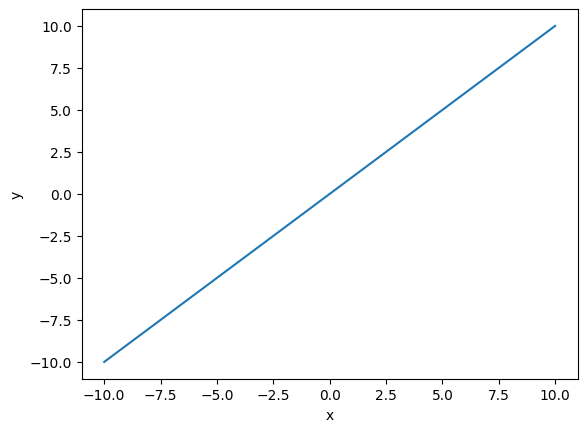

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


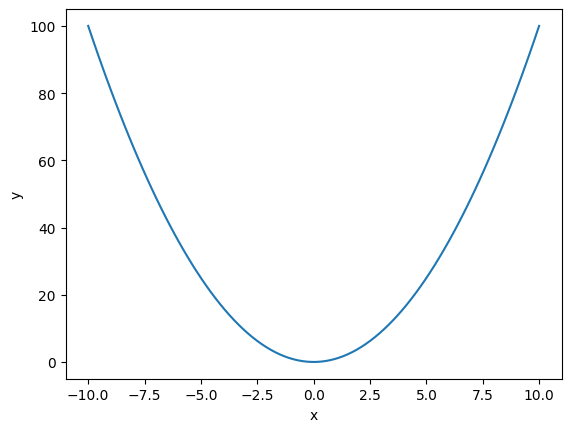

In [ ]:
# y= x^2
x=np.linspace(-10,10,100)
y=x**2

plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

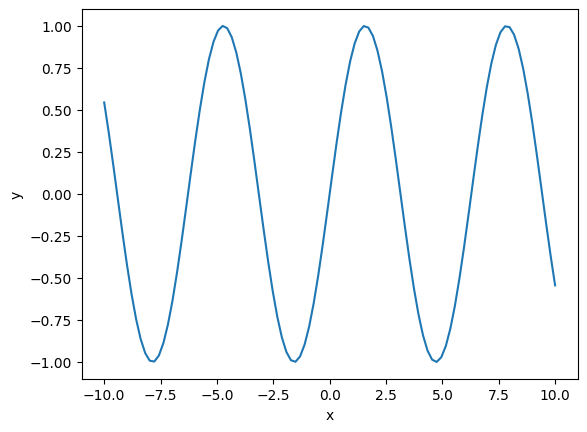

In [ ]:
# y=sin(x)

x=np.linspace(-10,10,100)
y=np.sin(x)

plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

/tmp/ipykernel_1217/3975899912.py:4: RuntimeWarning: invalid value encountered in log
  y=x*np.log(x)


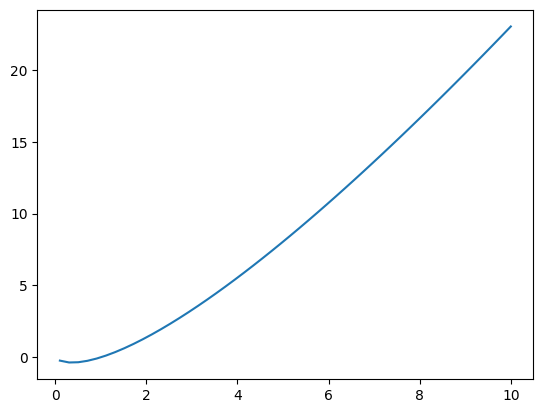

In [ ]:
# y=x.logx

x=np.linspace(-10,10,100)
y=x*np.log(x)


plt.plot(x,y)

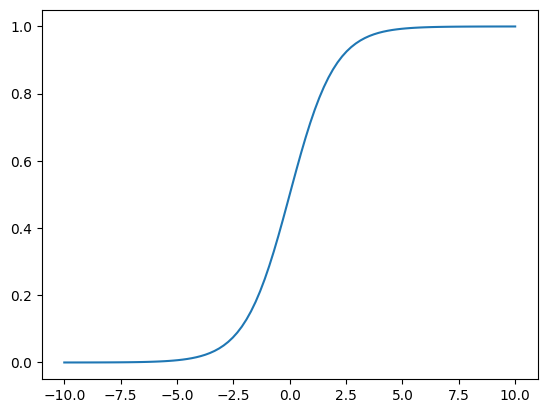

In [ ]:
# Sigmoid graph
x=np.linspace(-10,10,100)
y=1/(1+np.exp(-x))

plt.plot(x,y)

# **Numpy tricks- advance numpy**

np.sort  => return a sorted copy of an array.

In [ ]:
import numpy as np
a=np.random.randint(1,100,15)
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
np.sort(a)

array([ 7, 10, 23, 25, 27, 30, 31, 39, 42, 47, 48, 50, 69, 87, 91])

In [ ]:
b=np.random.randint(1,100,24).reshape(6,4)
b

array([[76, 31, 85, 49],
       [90, 92, 28, 97],
       [89, 77, 50,  9],
       [ 2, 45, 93, 21],
       [32, 79, 65, 55],
       [ 2, 50, 71, 24]])

In [ ]:
np.sort(b)
# row wise soting

array([[31, 49, 76, 85],
       [28, 90, 92, 97],
       [ 9, 50, 77, 89],
       [ 2, 21, 45, 93],
       [32, 55, 65, 79],
       [ 2, 24, 50, 71]])

# Concatenation

In [ ]:
#np.cancatente

c=np.arange(6).reshape(2,3)
d=np.arange(6,12).reshape(2,3)

print(c)
print(d)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]


In [ ]:
# row
np.concatenate((c,d),axis=0)


array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [ ]:
np.concatenate((c,d),axis=1)

array([[ 0,  1,  2,  6,  7,  8],
       [ 3,  4,  5,  9, 10, 11]])

# np.Unique

In [ ]:
e=np.array([1,1,2,2,3,3,4,4,5,5,6,6])
e

array([1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6])

In [ ]:
np.unique(e)

array([1, 2, 3, 4, 5, 6])

# np.expand_dims =>
 to make row and column vector or changing the dimenstion

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
a.shape

(15,)

In [ ]:
# column for 0
z=np.expand_dims(a,axis=0)
z

array([[23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2]])

In [ ]:
z.shape

(1, 15)

In [ ]:
z1=np.expand_dims(a,axis=1)
z1.shape

(15, 1)

# np.where

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
# find all indices with value greater than 50
np.where(a>50)

(array([ 1,  7,  8, 10, 12, 13]),)

In [ ]:
# replace all the values >50 wiht 0

np.where(a > 50 ,0 ,a)

array([23,  0, 50,  8, 18,  6, 48,  0,  0, 39,  0, 42,  0,  0,  2])

In [ ]:
np.where(a%2==0,0,a)

array([23,  0,  0,  0,  0,  0,  0, 93, 97, 39,  0,  0,  0,  0,  0])

np.argmax

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
# to find max element index
np.argmax(a)

np.int64(12)

In [ ]:
np.max(a)

np.int64(98)

In [ ]:
b=np.random.randint(1,100,24).reshape(6,4)
b

array([[75, 97, 56, 22],
       [12, 60,  2, 25],
       [65,  2, 28, 47],
       [91, 40, 84, 47],
       [ 4, 57, 49, 19],
       [ 6, 83, 16, 63]])

In [ ]:
# in column all maximum element indxcies
np.argmax(b,axis=0)

array([3, 0, 3, 5])

# np.argmin

In [ ]:
np.argmin(b,axis=0)

array([4, 2, 1, 4])

# np.cumsum
it is used to compute the nth perdentile of the given data (array elemnt) along the specified axis.

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
np.cumsum(a)

array([ 23, 117, 167, 175, 193, 199, 247, 340, 437, 476, 538, 580, 678,
       760, 762])

In [ ]:
np.cumsum(b, axis=0)

array([[ 75,  97,  56,  22],
       [ 87, 157,  58,  47],
       [152, 159,  86,  94],
       [243, 199, 170, 141],
       [247, 256, 219, 160],
       [253, 339, 235, 223]])

In [ ]:
np.cumsum(b,axis=1)

array([[ 75, 172, 228, 250],
       [ 12,  72,  74,  99],
       [ 65,  67,  95, 142],
       [ 91, 131, 215, 262],
       [  4,  61, 110, 129],
       [  6,  89, 105, 168]])

# cumulative product
np.cumprod

In [ ]:
np.cumprod(a)

array([                  23,                 2162,               108100,
                     864800,             15566400,             93398400,
                 4483123200,         416930457600,       40442254387200,
           1577247921100800,    97789371108249600,  4107153586546483200,
       -3327318140054781952,  3861073621151154176,  7722147242302308352])

# np.percentile

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
np.percentile(a,100)

np.float64(98.0)

In [ ]:
np.percentile(a,0)

np.float64(2.0)

In [ ]:
np.percentile(a,50)

np.float64(48.0)

In [ ]:
np.median(a)

np.float64(48.0)

# np.histogram =  
frequence chart

In [ ]:
a

array([23, 94, 50,  8, 18,  6, 48, 93, 97, 39, 62, 42, 98, 82,  2])

In [ ]:
np.histogram(a,bins=[0,10,20,30,40,50,60,70,80,90,100])

(array([3, 1, 1, 1, 2, 1, 1, 0, 1, 4]),
 array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100]))

In [ ]:
np.histogram(a,bins=[0,50,100])


(array([8, 7]), array([  0,  50, 100]))